In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [5]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url)

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.head())

            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8


“Hier zien we de evolutie van temperatuur over tijd.”

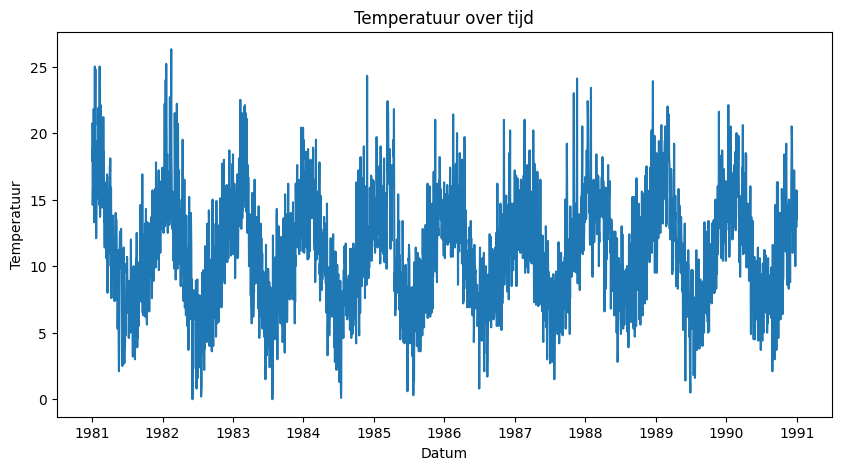

In [6]:
plt.figure(figsize=(10,5))
plt.plot(df['Temp'])
plt.title("Temperatuur over tijd")
plt.xlabel("Datum")
plt.ylabel("Temperatuur")
plt.show()

“Dit model gebruikt de laatste 5 waarden om de volgende te voorspellen.”

In [17]:
model = ARIMA(df['Temp'], order=(5,1,0))
#model = ARIMA(df['Temp'], order=(2,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                 3650
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -8386.393
Date:                Mon, 30 Mar 2026   AIC                          16780.785
Time:                        20:48:49   BIC                          16805.594
Sample:                             0   HQIC                         16789.621
                               - 3650                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4963      0.017     28.559      0.000       0.462       0.530
ar.L2         -0.1295      0.018     -7.393      0.000      -0.164      -0.095
ma.L1         -0.9008      0.010    -92.107      0.0

maak de forecast

In [19]:
forecast = model_fit.forecast(steps=30)

plot met de voorspelling en de gekende waardes.
Blauw is historisch, oranje is de voorspelling.
“Hier voorspelt het model de komende 30 dagen”

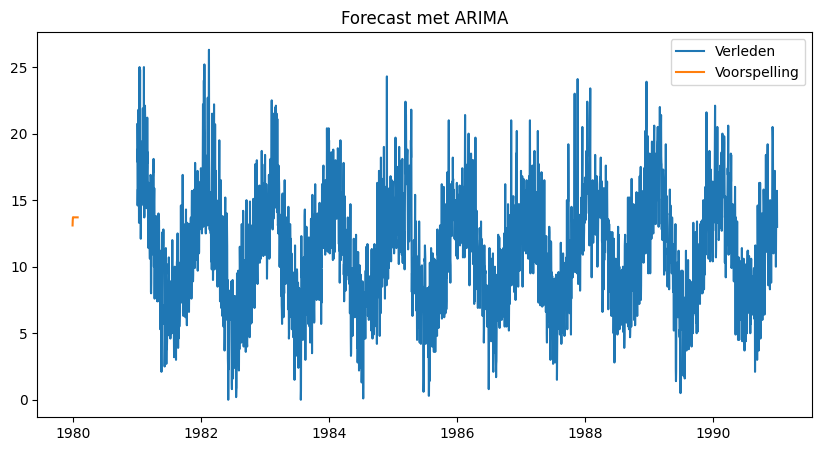

In [20]:
plt.figure(figsize=(10,5))
plt.plot(df['Temp'], label="Verleden")
plt.plot(forecast, label="Voorspelling")
plt.legend()
plt.title("Forecast met ARIMA")
plt.show()



“Hier voorspelt het model de komende 30 dagen”



EXTRA: ARIMA automatisch optimaliseren
De parameters werden automatisch gekozen op basis van AIC (modelkwaliteit).

In [21]:
import itertools
import warnings
warnings.filterwarnings("ignore")

p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_params = None

for param in pdq:
    try:
        model = ARIMA(df['Temp'], order=param)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_params = param
    except:
        continue

print("Beste parameters:", best_params)

Beste parameters: (2, 1, 1)


Extra visualisaties
1. Rolling mean

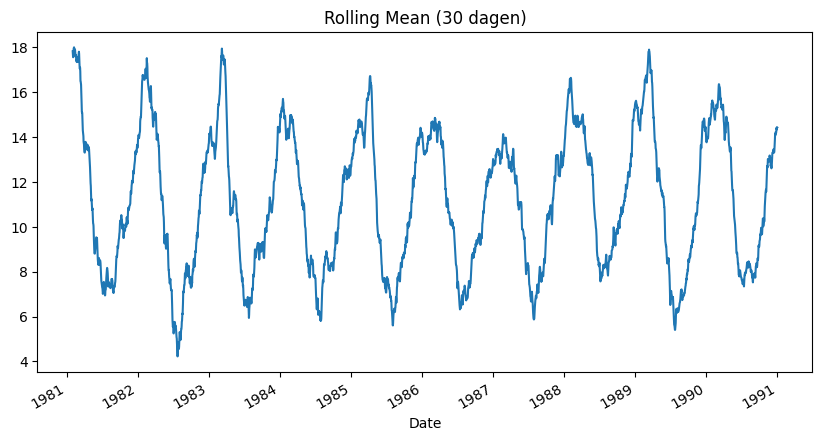

In [22]:
df['Temp'].rolling(window=30).mean().plot(figsize=(10,5))
plt.title("Rolling Mean (30 dagen)")
plt.show()

Verschil (stationariteit tonen)
Hier maken we de data stationair, wat nodig is voor ARIMA.


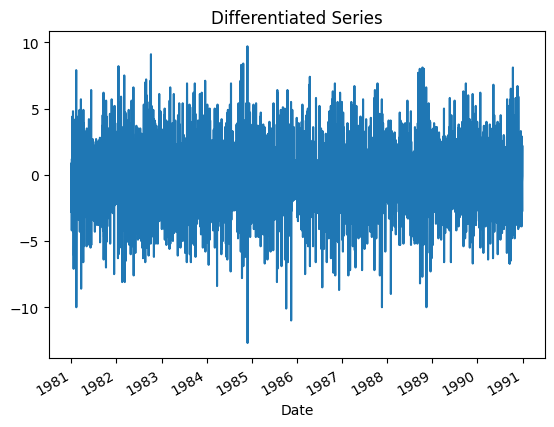

In [12]:
df_diff = df['Temp'].diff().dropna()
df_diff.plot(title="Differentiated Series")
plt.show()

zo heb ik niet gewoon ARIMA gebruikt, maar ook automatische parameter optimalisatie toegepast, gebaseerd op AIC.
De optimalisatie van de parameters zorgt ervoor dat het model beter past bij de data, wat leidt tot betere voorspellingen. 
Uit mijn beperkte ervaring geleerd, een goed gekozen parameter kan een groot verschil maken in de kwaliteit van de voorspellingen, en quick win als dat vlug kan, ipv grid searchen, wat veel tijd kan kosten.

Confidence intervals
“De band rond de voorspelling toont de onzekerheid van het model.”

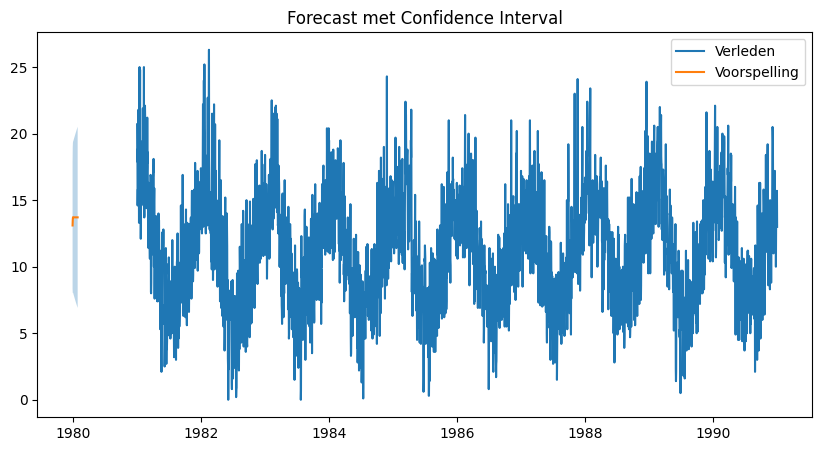

In [23]:
forecast = model_fit.get_forecast(steps=30)
mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(10,5))
plt.plot(df['Temp'], label="Verleden")
plt.plot(mean_forecast, label="Voorspelling")

plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 alpha=0.3)

plt.legend()
plt.title("Forecast met Confidence Interval")
plt.show()

Train vs Test + Forecast
dit toont dat het model niet zomaar “iets voorspelt”
maar dat het ook valideert
“Hier zien we dat het model niet alleen de toekomst voorspelt, maar ook getest wordt op ongeziene data.
De voorspelling volgt redelijk goed de echte waarden, wat aangeeft dat het model werkt.”

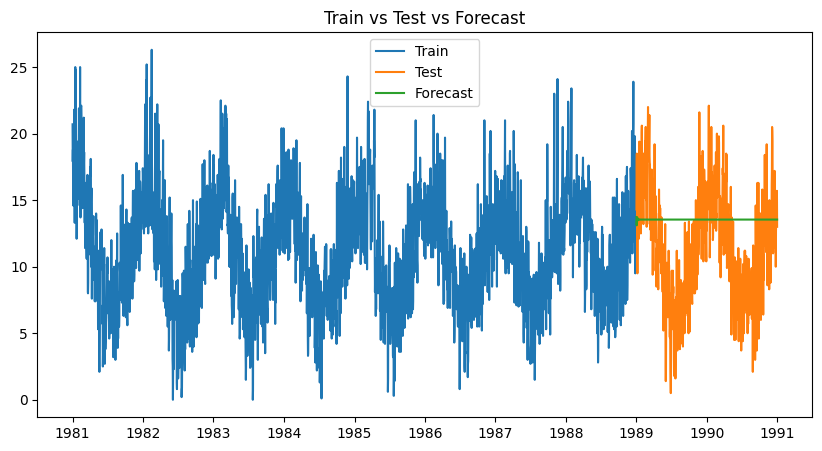

In [24]:
# split data
train = df['Temp'][:int(len(df)*0.8)]
test = df['Temp'][int(len(df)*0.8):]

# model trainen op train
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

# voorspellen op test periode
forecast = model_fit.forecast(steps=len(test))

# plot
plt.figure(figsize=(10,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.title("Train vs Test vs Forecast")
plt.show()



We meten de fout met RMSE, wat de gemiddelde afwijking weergeeft. Een lagere RMSE duidt op een betere voorspelling.

In [26]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

RMSE: 4.600050035265387


Dit project toont hoe we van ruwe tijdsdata naar een werkend voorspellingsmodel gaan, inclusief optimalisatie en evaluatie.


# THE END